 # Data Loading & Environment Setup



*   Mounting Drive





In [273]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


* loading Dataset

In [274]:
import pandas as pd
output_path = "/content/drive/MyDrive/MOT/mot_2018_2024_10percent_by_vehicle.csv.gz"
df1 = pd.read_csv(output_path, low_memory=False)


* Importing libraries

In [275]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [276]:
df1.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,colour,fuel_type,cylinder_capacity,first_use_date,mot_year,completed_date
0,1886686693,133782560,2018-01-01,4,NT,P,93737.0,B,ROVER,75,BLUE,DI,1951.0,2003-11-27,2018,NaN
1,649880599,1359750734,2018-01-01,4,NT,P,87226.0,B,MERCEDES-BENZ,B,BLUE,DI,1991.0,2007-06-28,2018,NaN
2,393989683,1145230428,2018-01-01,4,NT,P,112663.0,LU,BMW,3 SERIES,RED,PE,2497.0,2006-07-24,2018,NaN
3,1967504823,1017819996,2018-01-01,4,NT,P,174561.0,PR,BMW,530,GREY,DI,2926.0,2003-03-31,2018,NaN
4,180747253,1161058062,2018-01-01,4,NT,P,39556.0,B,MAZDA,2,RED,PE,1349.0,2009-10-16,2018,NaN


# Data Sampling

* "performing unique vehicle-id sampling to create a manageable subset for behavioral analysis."

In [277]:

vehicle_ids = df1["vehicle_id"].unique()
sample_ids = np.random.choice(
    vehicle_ids,
    size=20000,
    replace=False
)

In [278]:
df = df1[df1["vehicle_id"].isin(sample_ids)]

In [279]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,colour,fuel_type,cylinder_capacity,first_use_date,mot_year,completed_date
105,726418861,945956584,2018-01-02,4,NT,P,132811.0,CV,HONDA,CIVIC,BLUE,DI,2204.0,2008-03-28,2018,NaN
175,1384061519,336571628,2018-01-02,4,NT,F,203494.0,GU,BMW,3 SERIES,SILVER,DI,1995.0,2002-01-04,2018,NaN
984,1718082489,1184283069,2018-01-02,4,NT,P,50843.0,CB,BMW,3 SERIES,BLUE,DI,2993.0,2015-01-07,2018,NaN
1373,1537535991,1080232130,2018-01-02,4,NT,F,117125.0,HX,FORD,FOCUS,GREY,DI,1560.0,2008-07-31,2018,NaN
2188,1279005779,1319350473,2018-01-02,4,NT,P,16349.0,CF,FORD,FIESTA,SILVER,PE,1596.0,2014-12-29,2018,NaN


In [280]:
df = df.sort_values(
    ["vehicle_id", "test_date"]
)
df = df.reset_index(drop=True)

In [281]:
# 1. Get unique vehicles from your sampled 'df'
unique_cars = df['vehicle_id'].unique()

# 2. Select 600 vehicles to turn into "Suspects"
np.random.seed(42)
suspect_vids = np.random.choice(unique_cars, size=600, replace=False)

# Mark EVERYTHING as Normal first
df['synthetic_label'] = 'Normal'

# 3. Sort to ensure we are modifying the LATEST record
df = df.sort_values(['vehicle_id', 'test_date'])

# 4. Inject Synthetic Rollbacks (-10,000 miles)
for vid in suspect_vids:
    idx_list = df[df['vehicle_id'] == vid].index
    if len(idx_list) < 2: continue

    last_idx = idx_list[-1]
    prev_idx = idx_list[-2]
    prev_mileage = df.at[prev_idx, 'test_mileage']

    # Force a massive 10,000 mile rollback
    df.at[last_idx, 'test_mileage'] = max(0, prev_mileage - 10000)
    df.at[last_idx, 'synthetic_label'] = 'Rollback'

In [282]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,colour,fuel_type,cylinder_capacity,first_use_date,mot_year,completed_date,synthetic_label
0,377057623,88266,2018-01-03,4,NT,F,104685.0,BB,TOYOTA,YARIS,SILVER,PE,998.0,2005-09-02,2018,NaN,Normal
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,SILVER,PE,998.0,2005-09-02,2018,NaN,Normal
2,132621137,119597,2021-07-06,4,NT,P,26078.0,EH,MERCEDES-BENZ,A-CLASS,WHITE,PE,1991.0,2018-07-31,2022,NaN,Normal
3,1833452729,119597,2024-04-19,4,NT,P,57958.0,LN,MERCEDES-BENZ,A-CLASS,WHITE,PE,1991.0,2018-07-31,2024,2024-04-19T13:23:40.000Z,Normal
4,743785415,289005,2018-03-22,4,NT,P,48859.0,LL,VOLVO,V40,SILVER,DI,1560.0,2013-03-28,2018,NaN,Normal


# Data Pre-processing and Feature Engineering

* Standardizing dates to datetime formate.
* sorting dataframe by vehicle id and test dates.
* this step is crutial for calculating the miles_per_day and mileage_diff features which we use later in the anomaly detection.

In [283]:
# Convert date
df["test_date"] = pd.to_datetime(df["test_date"], errors="coerce")

# Sort properly
df = df.sort_values(["vehicle_id", "test_date"])

# Reset index
df = df.reset_index(drop=True)

print(" Data sorted properly")
df.head(10)

 Data sorted properly


,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,colour,fuel_type,cylinder_capacity,first_use_date,mot_year,completed_date,synthetic_label
0,377057623,88266,2018-01-03,4,NT,F,104685.0,BB,TOYOTA,YARIS,SILVER,PE,998.0,2005-09-02,2018,NaN,Normal
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,SILVER,PE,998.0,2005-09-02,2018,NaN,Normal
2,132621137,119597,2021-07-06,4,NT,P,26078.0,EH,MERCEDES-BENZ,A-CLASS,WHITE,PE,1991.0,2018-07-31,2022,NaN,Normal
3,1833452729,119597,2024-04-19,4,NT,P,57958.0,LN,MERCEDES-BENZ,A-CLASS,WHITE,PE,1991.0,2018-07-31,2024,2024-04-19T13:23:40.000Z,Normal
4,743785415,289005,2018-03-22,4,NT,P,48859.0,LL,VOLVO,V40,SILVER,DI,1560.0,2013-03-28,2018,NaN,Normal
5,1054452821,289005,2019-03-25,4,NT,P,62141.0,LL,VOLVO,V40,SILVER,DI,1560.0,2013-03-28,2019,NaN,Normal
6,1432974215,289005,2020-03-25,4,NT,P,83567.0,LL,VOLVO,V40,SILVER,DI,1560.0,2013-03-28,2020,NaN,Normal
7,906297253,289005,2021-03-12,4,NT,P,96608.0,LL,VOLVO,V40,SILVER,DI,1560.0,2013-03-28,2022,NaN,Normal
8,1897903141,289005,2024-01-25,4,NT,P,143661.0,B,VOLVO,V40,SILVER,DI,1560.0,2013-03-28,2024,2024-01-25T16:30:05.000Z,Normal
9,1897903141,289005,2024-01-25,4,NT,P,143661.0,B,VOLVO,V40,SILVER,DI,1560.0,2013-03-28,2024,2024-01-25T16:30:05.000Z,Normal


# Core features

* Now that we have sorted our dataset, we will see how the car has been driven between each MOT test

**What we are creating here**


*   Previous Mileage: previous mot test mileage.
*   Mileage difference: difference of mileage between previous and current MOT test.
*   Days difference: Days differnce between previoius MOT test and current MOT test.
*   Miles per day: This is the most important feature it will tell us the how many miles car have been driven from previous till currunt MOT on daily basis. which will give us the intensity of the car use



In [284]:
# Previous mileage
df["prev_mileage"] = df.groupby("vehicle_id")["test_mileage"].shift(1)

# Mileage difference
df["mileage_diff"] = df["test_mileage"] - df["prev_mileage"]

# Days difference
df["prev_test_date"] = df.groupby("vehicle_id")["test_date"].shift(1)
df["days_diff"] = (df["test_date"] - df["prev_test_date"]).dt.days
df = df[df["days_diff"] > 0]
# Miles per day
df["miles_per_day"] = df["mileage_diff"] / df["days_diff"]

print("Core features created")
df[["vehicle_id","test_mileage","prev_mileage","mileage_diff","days_diff","miles_per_day"]].head(10)

Core features created


,vehicle_id,test_mileage,prev_mileage,mileage_diff,days_diff,miles_per_day
1,88266,104686.0,104685.0,1.0,5.0,0.200000
3,119597,57958.0,26078.0,31880.0,1018.0,31.316306
5,289005,62141.0,48859.0,13282.0,368.0,36.092391
6,289005,83567.0,62141.0,21426.0,366.0,58.540984
7,289005,96608.0,83567.0,13041.0,352.0,37.048295
8,289005,143661.0,96608.0,47053.0,1049.0,44.855100
11,299306,127414.0,127411.0,3.0,6.0,0.500000
12,299306,130875.0,127414.0,3461.0,369.0,9.379404
14,299306,133285.0,170825.0,-37540.0,373.0,-100.643432
15,299306,135762.0,133285.0,2477.0,369.0,6.712737


* Detecting Behavioral Shifts (Year-over-Year)




**Finding the sneaky Rollbacks.**
* In this section we will compare the vehicle intensity of driving to its own performance in previous year.
* A car might show a positive milage for example 3000, but if it was doing 15000 mile every year previously that sudden drop could be a major red flag.
* **Usage Trend Shift**: this feature will create a ratio of current year mileage speed and previous year milage speed.
* A value of near 0 mean usage rate drop which is common odometer temparing and near 1 mean car is driven consistently.

In [285]:
# Compare current usage to the PREVIOUS year's usage specifically
df['prev_year_miles_per_day'] = df.groupby('vehicle_id')['miles_per_day'].shift(1)
df['usage_trend_shift'] = df['miles_per_day'] / df['prev_year_miles_per_day']

In [286]:
df.head(10)

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,mot_year,completed_date,synthetic_label,prev_mileage,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,...,2018,NaN,Normal,104685.0,1.0,2018-01-03,5.0,0.200000,NaN,NaN
3,1833452729,119597,2024-04-19,4,NT,P,57958.0,LN,MERCEDES-BENZ,A-CLASS,...,2024,2024-04-19T13:23:40.000Z,Normal,26078.0,31880.0,2021-07-06,1018.0,31.316306,NaN,NaN
5,1054452821,289005,2019-03-25,4,NT,P,62141.0,LL,VOLVO,V40,...,2019,NaN,Normal,48859.0,13282.0,2018-03-22,368.0,36.092391,NaN,NaN
6,1432974215,289005,2020-03-25,4,NT,P,83567.0,LL,VOLVO,V40,...,2020,NaN,Normal,62141.0,21426.0,2019-03-25,366.0,58.540984,36.092391,1.621976
7,906297253,289005,2021-03-12,4,NT,P,96608.0,LL,VOLVO,V40,...,2022,NaN,Normal,83567.0,13041.0,2020-03-25,352.0,37.048295,58.540984,0.632861
8,1897903141,289005,2024-01-25,4,NT,P,143661.0,B,VOLVO,V40,...,2024,2024-01-25T16:30:05.000Z,Normal,96608.0,47053.0,2021-03-12,1049.0,44.855100,37.048295,1.210720
11,1151628137,299306,2018-09-12,4,RT,P,127414.0,IP,VOLVO,940,...,2018,NaN,Normal,127411.0,3.0,2018-09-06,6.0,0.500000,NaN,NaN
12,360522213,299306,2019-09-16,4,NT,F,130875.0,IP,VOLVO,940,...,2019,NaN,Normal,127414.0,3461.0,2018-09-12,369.0,9.379404,0.500000,18.758808
14,1583726015,299306,2020-09-23,4,NT,P,133285.0,IP,VOLVO,940,...,2020,NaN,Normal,170825.0,-37540.0,2019-09-16,373.0,-100.643432,9.379404,-10.730259
15,666374113,299306,2021-09-27,4,NT,F,135762.0,IP,VOLVO,900 Series,...,2022,NaN,Normal,133285.0,2477.0,2020-09-23,369.0,6.712737,-100.643432,-0.066698


* checking the shape of our dataset.

In [287]:
df.shape

(57903, 24)

* here we will keep the rows where if the days differnce between previous MOT and current MOT is greater than 0.

In [288]:
df = df[df["days_diff"] > 0]
df = df.dropna(subset=["mileage_diff", "days_diff"])

print(" Cleaned dataset shape:", df.shape)

 Cleaned dataset shape: (56914, 24)


* Checking if there are any null values in our Dataset.

In [289]:
df.isnull().sum()

,0
test_id,0
vehicle_id,0
test_date,0
test_class_id,0
test_type,0
test_result,0
test_mileage,0
postcode_area,0
make,0
model,0


In [290]:
df.columns

Index(['test_id', 'vehicle_id', 'test_date', 'test_class_id', 'test_type',
       'test_result', 'test_mileage', 'postcode_area', 'make', 'model',
       'colour', 'fuel_type', 'cylinder_capacity', 'first_use_date',
       'mot_year', 'completed_date', 'synthetic_label', 'prev_mileage',
       'mileage_diff', 'prev_test_date', 'days_diff', 'miles_per_day',
       'prev_year_miles_per_day', 'usage_trend_shift'],
      dtype='object')

In [291]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,mot_year,completed_date,synthetic_label,prev_mileage,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,...,2018,NaN,Normal,104685.0,1.0,2018-01-03,5.0,0.200000,NaN,NaN
3,1833452729,119597,2024-04-19,4,NT,P,57958.0,LN,MERCEDES-BENZ,A-CLASS,...,2024,2024-04-19T13:23:40.000Z,Normal,26078.0,31880.0,2021-07-06,1018.0,31.316306,NaN,NaN
5,1054452821,289005,2019-03-25,4,NT,P,62141.0,LL,VOLVO,V40,...,2019,NaN,Normal,48859.0,13282.0,2018-03-22,368.0,36.092391,NaN,NaN
6,1432974215,289005,2020-03-25,4,NT,P,83567.0,LL,VOLVO,V40,...,2020,NaN,Normal,62141.0,21426.0,2019-03-25,366.0,58.540984,36.092391,1.621976
7,906297253,289005,2021-03-12,4,NT,P,96608.0,LL,VOLVO,V40,...,2022,NaN,Normal,83567.0,13041.0,2020-03-25,352.0,37.048295,58.540984,0.632861


In [292]:
df["test_date"] = pd.to_datetime(df["test_date"])
df["first_use_date"] = pd.to_datetime(df["first_use_date"])
df["car_age_at_test"] = (
    (df["test_date"] - df["first_use_date"])
    .dt.days / 365.25
)

In [293]:
#df.columns

In [294]:
# 1. Ensure data is sorted so the history flows correctly
df = df.sort_values(['vehicle_id', 'test_date'])

# 2. Calculate the Cumulative Average miles per day for each vehicle
# This gives us the "Normal" behavior for THAT specific car
df['hist_avg_miles_per_day'] = df.groupby('vehicle_id')['miles_per_day'].expanding().mean().reset_index(level=0, drop=True)

# 3. Create the Ratio (The Fraud Detector)
# If this is 1.0, the car is driven consistently.
# If it's 0.5, the car suddenly 'lost' half its daily usage.
df['usage_consistency_ratio'] = df['miles_per_day'] / df['hist_avg_miles_per_day']

In [295]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,prev_mileage,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,...,104685.0,1.0,2018-01-03,5.0,0.200000,NaN,NaN,12.350445,0.200000,1.000000
3,1833452729,119597,2024-04-19,4,NT,P,57958.0,LN,MERCEDES-BENZ,A-CLASS,...,26078.0,31880.0,2021-07-06,1018.0,31.316306,NaN,NaN,5.719370,31.316306,1.000000
5,1054452821,289005,2019-03-25,4,NT,P,62141.0,LL,VOLVO,V40,...,48859.0,13282.0,2018-03-22,368.0,36.092391,NaN,NaN,5.990418,36.092391,1.000000
6,1432974215,289005,2020-03-25,4,NT,P,83567.0,LL,VOLVO,V40,...,62141.0,21426.0,2019-03-25,366.0,58.540984,36.092391,1.621976,6.992471,47.316687,1.237216
7,906297253,289005,2021-03-12,4,NT,P,96608.0,LL,VOLVO,V40,...,83567.0,13041.0,2020-03-25,352.0,37.048295,58.540984,0.632861,7.956194,43.893890,0.844042


In [296]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,prev_mileage,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,...,104685.0,1.0,2018-01-03,5.0,0.200000,NaN,NaN,12.350445,0.200000,1.000000
3,1833452729,119597,2024-04-19,4,NT,P,57958.0,LN,MERCEDES-BENZ,A-CLASS,...,26078.0,31880.0,2021-07-06,1018.0,31.316306,NaN,NaN,5.719370,31.316306,1.000000
5,1054452821,289005,2019-03-25,4,NT,P,62141.0,LL,VOLVO,V40,...,48859.0,13282.0,2018-03-22,368.0,36.092391,NaN,NaN,5.990418,36.092391,1.000000
6,1432974215,289005,2020-03-25,4,NT,P,83567.0,LL,VOLVO,V40,...,62141.0,21426.0,2019-03-25,366.0,58.540984,36.092391,1.621976,6.992471,47.316687,1.237216
7,906297253,289005,2021-03-12,4,NT,P,96608.0,LL,VOLVO,V40,...,83567.0,13041.0,2020-03-25,352.0,37.048295,58.540984,0.632861,7.956194,43.893890,0.844042


In [297]:
df.isnull().sum()


,0
test_id,0
vehicle_id,0
test_date,0
test_class_id,0
test_type,0
test_result,0
test_mileage,0
postcode_area,0
make,0
model,0


In [298]:
# Create the 'is_first_record' flag based on your Null counts
df['is_first_record'] = df['prev_year_miles_per_day'].isna()

# Create your ML-Ready dataset (The 'Clean' rows)
# This removes the 16,438 rows that don't have enough history
df_ml = df[df['is_first_record'] == False].copy()

# Fix the 821 ratio errors by dropping them or filling with 1.0
# (Dropping is safer for fraud detection)
df_ml = df_ml.dropna(subset=['usage_consistency_ratio'])

print(f"Original rows: {len(df)}")
print(f"Rows ready for Fraud Detection: {len(df_ml)}")

Original rows: 56914
Rows ready for Fraud Detection: 40499


In [299]:
df_ml.isnull().sum()

,0
test_id,0
vehicle_id,0
test_date,0
test_class_id,0
test_type,0
test_result,0
test_mileage,0
postcode_area,0
make,0
model,0


In [300]:
df_ml.loc[(df_ml['mileage_diff'] < 0) & (df_ml['synthetic_label'] == 'Normal'), 'synthetic_label'] = 'Negative_Mileage'

In [301]:
# 1. Identify all Anomalies (Your 3 Personas + Natural Negatives)
# 'synthetic_label' will be 'Normal' for honest cars, and something else for suspects
is_anomaly = (df_ml['synthetic_label'] != 'Normal') | (df_ml['mileage_diff'] < 0)

# 2. Extract the Forensic Test Set (The Fraudsters)
df_forensic_test = df_ml[is_anomaly].copy()

# 3. Purify the main df_ml (The Honest Cars)
# We overwrite df_ml to contain only the 'Normal' records
df_ml = df_ml[~is_anomaly].copy()

print(f"--- Separation Complete ---")
print(f"Main dataset (df_ml) now has {len(df_ml)} clean records for training.")
print(f"Forensic dataset (df_forensic_test) has {len(df_forensic_test)} records for testing.")

--- Separation Complete ---
Main dataset (df_ml) now has 39992 clean records for training.
Forensic dataset (df_forensic_test) has 507 records for testing.


In [302]:
df_forensic_test['synthetic_label'].value_counts()


,count
synthetic_label,
Rollback,282
Negative_Mileage,225


In [303]:
df_ml=df_ml[df_ml["mileage_diff"] > 0]

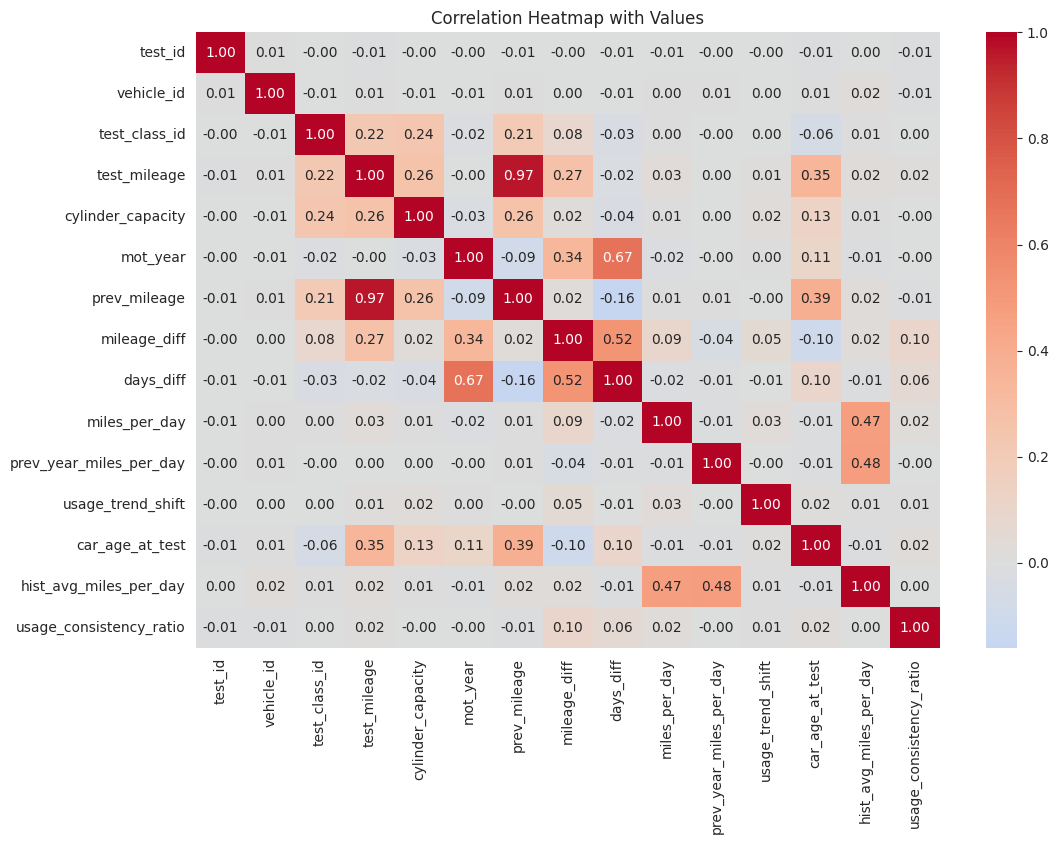

In [304]:

# Select numeric columns
df_numeric = df_ml.select_dtypes(include="number")

# Correlation matrix
corr_matrix = df_numeric.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap with Values")
plt.show()

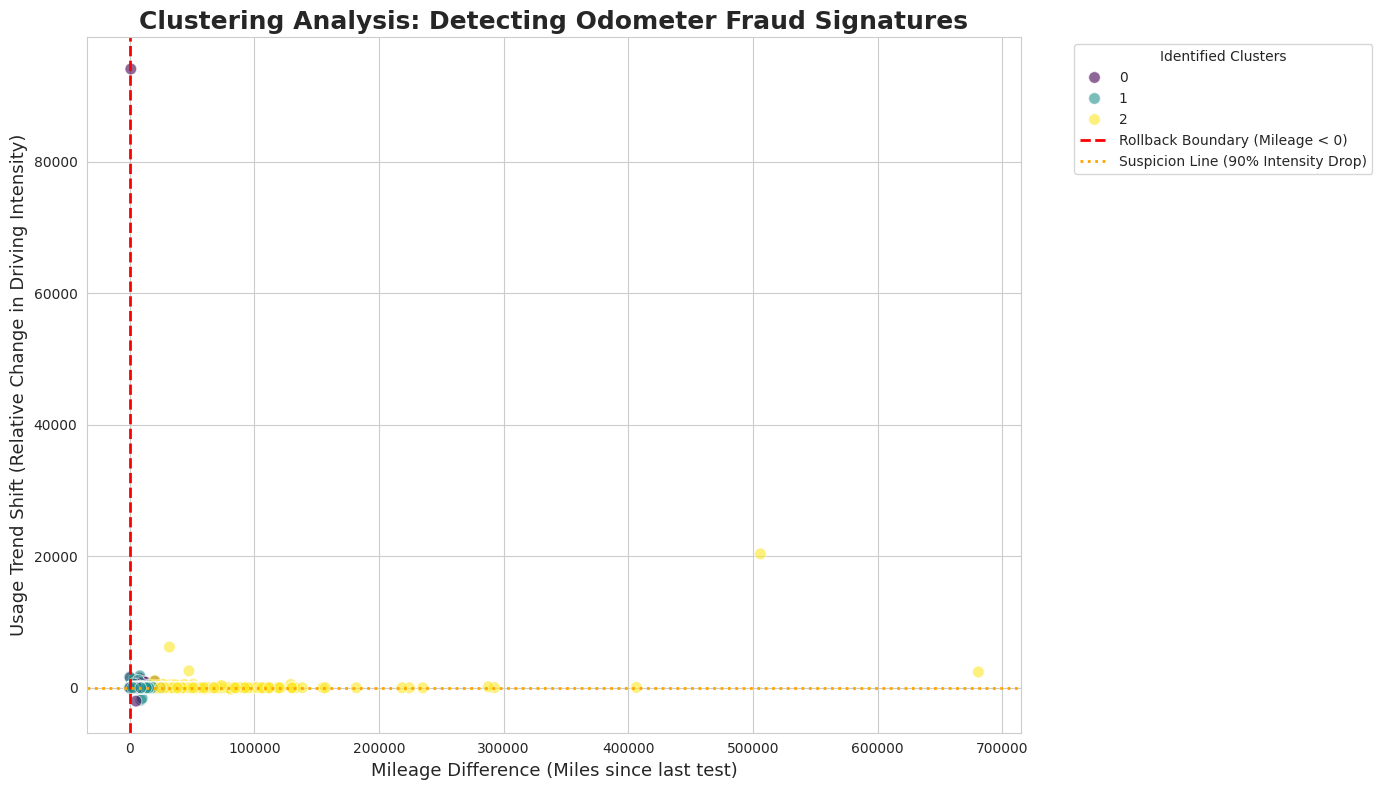

In [305]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. CLEANING & CAPPING (Fixing the ValueError)
df_viz = df_ml.copy()

# We replace Infinities with a fixed value (-10) so the Scaler can process them.
# This preserves the "signal" of a massive drop without breaking the math.
cols_to_fix = ['usage_trend_shift', 'usage_consistency_ratio']
df_viz[cols_to_fix] = df_viz[cols_to_fix].replace([np.inf, -np.inf], -10).fillna(0)

# 2. FEATURE SCALING
scaler = StandardScaler()
features_for_clustering = ['mileage_diff', 'usage_trend_shift', 'usage_consistency_ratio', 'car_age_at_test']
scaled_data = scaler.fit_transform(df_viz[features_for_clustering])

# 3. K-MEANS CLUSTERING (Pattern Discovery)
# We use 3 clusters: Normal, Obvious Fraud, and Sneaky Fraud
kmeans = KMeans(n_clusters=3, random_state=42)
df_viz['cluster'] = kmeans.fit_predict(scaled_data)

# 4. THE GRAPH (Visualizing the Fraud Signatures)
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Plotting Mileage Growth vs. Usage Shift
scatter = sns.scatterplot(
    data=df_viz,
    x='mileage_diff',
    y='usage_trend_shift',
    hue='cluster',
    palette='viridis',
    alpha=0.6,
    s=70
)

# Adding forensic reference lines
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Rollback Boundary (Mileage < 0)')
plt.axhline(y=0.2, color='orange', linestyle=':', linewidth=2, label='Suspicion Line (90% Intensity Drop)')

# Titles and Labels for the Meeting
plt.title('Clustering Analysis: Detecting Odometer Fraud Signatures', fontsize=18, fontweight='bold')
plt.xlabel('Mileage Difference (Miles since last test)', fontsize=13)
plt.ylabel('Usage Trend Shift (Relative Change in Driving Intensity)', fontsize=13)
plt.legend(title='Identified Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [306]:
df_ml.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record
6,1432974215,289005,2020-03-25,4,NT,P,83567.0,LL,VOLVO,V40,...,21426.0,2019-03-25,366.0,58.540984,36.092391,1.621976,6.992471,47.316687,1.237216,False
7,906297253,289005,2021-03-12,4,NT,P,96608.0,LL,VOLVO,V40,...,13041.0,2020-03-25,352.0,37.048295,58.540984,0.632861,7.956194,43.893890,0.844042,False
8,1897903141,289005,2024-01-25,4,NT,P,143661.0,B,VOLVO,V40,...,47053.0,2021-03-12,1049.0,44.855100,37.048295,1.210720,10.828200,44.134193,1.016334,False
12,360522213,299306,2019-09-16,4,NT,F,130875.0,IP,VOLVO,940,...,3461.0,2018-09-12,369.0,9.379404,0.500000,18.758808,21.530459,4.939702,1.898779,False
15,666374113,299306,2021-09-27,4,NT,F,135762.0,IP,VOLVO,900 Series,...,2477.0,2020-09-23,369.0,6.712737,-100.643432,-0.066698,23.561944,-21.012823,-0.319459,False


In [307]:
from sklearn.ensemble import IsolationForest

# 1. Define the 'Behavioral' features
# These are the columns that 'reveal' the fraud
features = [
    'mileage_diff',
    'miles_per_day',
    'usage_trend_shift',
    'usage_consistency_ratio',
    'car_age_at_test'
]

# 2. Initialize the model
# contamination=0.01 means we expect roughly 1% of the data to be 'weird'
iso_model = IsolationForest(contamination=0.03, random_state=42)

# 3. Predict Anomalies
# -1 = Suspicious / 1 = Normal
df_ml['anomaly_flag'] = iso_model.fit_predict(df_ml[features])

# 4. Get the 'Suspicion Score'
# Lower (more negative) scores mean the car is more likely to be fraudulent
df_ml['anomaly_score'] = iso_model.decision_function(df_ml[features])

In [308]:
# Create a list of 'High Risk' vehicles
# We look for anomalies where the mileage growth slowed down by more than 70%
high_risk_fraud = df_ml[
    (df_ml['anomaly_flag'] == -1) &
    (df_ml['usage_trend_shift'] < 0.3)
].sort_values(by='anomaly_score')

# Show the top 10 most suspicious cases
print(high_risk_fraud[['vehicle_id', 'make', 'model', 'test_mileage', 'mileage_diff', 'usage_trend_shift']].head(10))

       vehicle_id      make               model  test_mileage  mileage_diff  \
71282  1121378962    TOYOTA               PRIUS      262894.0      235197.0   
40342   634171490      FIAT               SCUDO      351721.0      133135.0   
25803   406247596  VAUXHALL               CORSA       60350.0       53684.0   
3362     50706356    TOYOTA  LANDCRUISER ESTATE      169711.0       60000.0   
35183   557451712   CITROEN                  C3      146350.0      112244.0   
22662   354155368       BMW                 520      265804.0      121153.0   
53143   831636398      SAAB                 9-5      132399.0      120064.0   
89351  1407370476      MINI                MINI       90133.0       81012.0   
68476  1076871685      FORD              FIESTA       82602.0       61671.0   
51195   799983997     SKODA               FABIA       32124.0        9001.0   

       usage_trend_shift  
71282          -2.046494  
40342          -1.545919  
25803        -113.382301  
3362         -194.9971

In [309]:
df_ml[df_ml['mileage_diff'] < 0].head(20)

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record,anomaly_flag,anomaly_score


In [310]:

df_ml[(df_ml['mileage_diff'] < 0) & (df_ml['anomaly_flag'] == -1)].shape[0]

0

In [311]:

df_ml[(df_ml['mileage_diff'] < 0) & (df_ml['anomaly_flag'] == 1)].shape[0]

0

In [312]:
df_ml[(df_ml['mileage_diff'] > 0) & (df_ml['anomaly_flag'] == 1)].shape[0]

36645

In [313]:
df_ml[(df_ml['mileage_diff'] > 0) & (df_ml['anomaly_flag'] == -1)].shape[0]

1134

In [314]:
# Capture the records the model hasn't seen yet
df_negatives = df[df['mileage_diff'] < 0].copy()

# Apply the same "math fixes" so the model doesn't crash
df_negatives['usage_trend_shift'] = df_negatives['usage_trend_shift'].replace([np.inf, -np.inf], -10).fillna(-10)
df_negatives['usage_consistency_ratio'] = df_negatives['usage_consistency_ratio'].replace([np.inf, -np.inf], -10).fillna(-10)
df_negatives['hist_avg_miles_per_day'] = df_negatives['hist_avg_miles_per_day'].fillna(0)

In [315]:
# Use the exact same features you used for training
features = [
    'mileage_diff',
    'miles_per_day',
    'usage_trend_shift',
    'usage_consistency_ratio',
    'car_age_at_test'
]

# Predict anomalies on the negative data
df_negatives['anomaly_flag'] = iso_model.predict(df_negatives[features])
df_negatives['anomaly_score'] = iso_model.decision_function(df_negatives[features])

In [316]:
detection_rate = (df_negatives['anomaly_flag'] == -1).mean() * 100
print(f"The model identified {detection_rate:.2f}% of negative mileage as fraud.")

# Look at the 'scores'
# A very low negative score means the model thinks these are EXTREMELY weird
print(df_negatives[['vehicle_id', 'mileage_diff', 'anomaly_score','anomaly_flag']].head(2030))

The model identified 99.85% of negative mileage as fraud.
       vehicle_id  mileage_diff  anomaly_score  anomaly_flag
14         299306      -37540.0      -0.200763            -1
220       3611264      -43495.0      -0.134101            -1
517       7871798      -38404.0      -0.218694            -1
562       8744306       -7631.0      -0.191006            -1
576       9043916      -10000.0      -0.078660            -1
...           ...           ...            ...           ...
94056  1485857088      -10000.0      -0.207431            -1
94267  1488852751      -10000.0      -0.123643            -1
94477  1492431656      -10000.0      -0.206873            -1
94545  1493182584     -114086.0      -0.214763            -1
94598  1494230972      -12721.0      -0.088065            -1

[654 rows x 4 columns]


In [317]:
df_ml.shape

(37779, 30)

In [318]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,...,1.0,2018-01-03,5.0,0.200000,NaN,NaN,12.350445,0.200000,1.000000,True
3,1833452729,119597,2024-04-19,4,NT,P,57958.0,LN,MERCEDES-BENZ,A-CLASS,...,31880.0,2021-07-06,1018.0,31.316306,NaN,NaN,5.719370,31.316306,1.000000,True
5,1054452821,289005,2019-03-25,4,NT,P,62141.0,LL,VOLVO,V40,...,13282.0,2018-03-22,368.0,36.092391,NaN,NaN,5.990418,36.092391,1.000000,True
6,1432974215,289005,2020-03-25,4,NT,P,83567.0,LL,VOLVO,V40,...,21426.0,2019-03-25,366.0,58.540984,36.092391,1.621976,6.992471,47.316687,1.237216,False
7,906297253,289005,2021-03-12,4,NT,P,96608.0,LL,VOLVO,V40,...,13041.0,2020-03-25,352.0,37.048295,58.540984,0.632861,7.956194,43.893890,0.844042,False


In [319]:
df_ml1 = df.head(10000).copy()

In [320]:
import pandas as pd
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# 1. Define the features for the model
features_lof = ['mileage_diff', 'usage_trend_shift', 'usage_consistency_ratio', 'car_age_at_test']

# 2. DATA CLEANING (Mandatory for LOF)
# This fixes the 'ValueError: Input contains infinity'
# We cap Infinities at -10 to signal a 'massive usage drop' to the model
df_ml1[features_lof] = df_ml1[features_lof].replace([np.inf, -np.inf], -10).fillna(0)

# 3. FEATURE SCALING
# LOF is distance-based; without scaling, 'mileage_diff' would dominate the math
scaler = StandardScaler()
scaled_lof_data = scaler.fit_transform(df_ml1[features_lof])

# 4. INITIALIZE LOF
# n_neighbors=20: Compare each car to its 20 nearest behavioral neighbors
# contamination=0.02: We expect roughly 2% of the fleet to be anomalous
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.10)

# 5. RUN MODEL
# -1 = Anomaly, 1 = Normal
df_ml1['lof_anomaly_flag'] = lof.fit_predict(scaled_lof_data)

# 6. CALCULATE ANOMALY SCORES
# The more negative the score, the more 'outlier' the vehicle is
df_ml1['lof_score'] = lof.negative_outlier_factor_

print("LOF Model training complete.")
print(f"Detected {len(df_ml1[df_ml1['lof_anomaly_flag'] == -1])} local anomalies.")

LOF Model training complete.
Detected 1000 local anomalies.


In [321]:
df_ml1.head(40)

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record,lof_anomaly_flag,lof_score
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,...,5.0,0.200000,NaN,0.000000,12.350445,0.200000,1.000000,True,1,-1.196111
3,1833452729,119597,2024-04-19,4,NT,P,57958.0,LN,MERCEDES-BENZ,A-CLASS,...,1018.0,31.316306,NaN,0.000000,5.719370,31.316306,1.000000,True,1,-1.015912
5,1054452821,289005,2019-03-25,4,NT,P,62141.0,LL,VOLVO,V40,...,368.0,36.092391,NaN,0.000000,5.990418,36.092391,1.000000,True,1,-0.967482
6,1432974215,289005,2020-03-25,4,NT,P,83567.0,LL,VOLVO,V40,...,366.0,58.540984,36.092391,1.621976,6.992471,47.316687,1.237216,False,1,-1.017870
7,906297253,289005,2021-03-12,4,NT,P,96608.0,LL,VOLVO,V40,...,352.0,37.048295,58.540984,0.632861,7.956194,43.893890,0.844042,False,1,-1.065967
8,1897903141,289005,2024-01-25,4,NT,P,143661.0,B,VOLVO,V40,...,1049.0,44.855100,37.048295,1.210720,10.828200,44.134193,1.016334,False,1,-1.199683
11,1151628137,299306,2018-09-12,4,RT,P,127414.0,IP,VOLVO,940,...,6.0,0.500000,NaN,0.000000,20.520192,0.500000,1.000000,True,1,-1.003849
12,360522213,299306,2019-09-16,4,NT,F,130875.0,IP,VOLVO,940,...,369.0,9.379404,0.500000,18.758808,21.530459,4.939702,1.898779,False,1,-1.078021
14,1583726015,299306,2020-09-23,4,NT,P,133285.0,IP,VOLVO,940,...,373.0,-100.643432,9.379404,-10.730259,22.551677,-30.254676,3.326541,False,-1,-2.504543
15,666374113,299306,2021-09-27,4,NT,F,135762.0,IP,VOLVO,900 Series,...,369.0,6.712737,-100.643432,-0.066698,23.561944,-21.012823,-0.319459,False,-1,-2.065894


In [322]:
df_ml.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record,anomaly_flag,anomaly_score
6,1432974215,289005,2020-03-25,4,NT,P,83567.0,LL,VOLVO,V40,...,366.0,58.540984,36.092391,1.621976,6.992471,47.316687,1.237216,False,1,0.076474
7,906297253,289005,2021-03-12,4,NT,P,96608.0,LL,VOLVO,V40,...,352.0,37.048295,58.540984,0.632861,7.956194,43.893890,0.844042,False,1,0.134847
8,1897903141,289005,2024-01-25,4,NT,P,143661.0,B,VOLVO,V40,...,1049.0,44.855100,37.048295,1.210720,10.828200,44.134193,1.016334,False,1,0.037298
12,360522213,299306,2019-09-16,4,NT,F,130875.0,IP,VOLVO,940,...,369.0,9.379404,0.500000,18.758808,21.530459,4.939702,1.898779,False,1,0.095977
15,666374113,299306,2021-09-27,4,NT,F,135762.0,IP,VOLVO,900 Series,...,369.0,6.712737,-100.643432,-0.066698,23.561944,-21.012823,-0.319459,False,-1,-0.089544


In [323]:
# 1. Capture the records (exactly as you did for Isolation Forest)
df_negatives_lof = df[df['mileage_diff'] < 0].copy()

# 2. Apply the same "math fixes" to prevent crashes
df_negatives_lof['usage_trend_shift'] = df_negatives_lof['usage_trend_shift'].replace([np.inf, -np.inf], -10).fillna(-10)
df_negatives_lof['usage_consistency_ratio'] = df_negatives_lof['usage_consistency_ratio'].replace([np.inf, -np.inf], -10).fillna(-10)
df_negatives_lof['hist_avg_miles_per_day'] = df_negatives_lof['hist_avg_miles_per_day'].fillna(0)

# 3. Use the exact same features
features_lof = [
    'mileage_diff',
    'miles_per_day',
    'usage_trend_shift',
    'usage_consistency_ratio',
    'car_age_at_test'
]

# 4. SCALE the data (MANDATORY for LOF)
# LOF calculates distances, so features must be on the same scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_negatives = scaler.fit_transform(df_negatives_lof[features_lof])

# 5. Predict anomalies using LOF
# We use fit_predict to get the flags for this specific batch
df_negatives_lof['lof_anomaly_flag'] = lof.fit_predict(scaled_negatives)

# LOF uses "negative_outlier_factor_" as its score
df_negatives_lof['lof_score'] = lof.negative_outlier_factor_

# 6. Calculate Detection Rate
lof_detection_rate = (df_negatives_lof['lof_anomaly_flag'] == -1).mean() * 100
print(f"The LOF model identified {lof_detection_rate:.2f}% of negative mileage as fraud.")

# 7. Look at the 'scores'
print(df_negatives_lof[['vehicle_id', 'mileage_diff', 'lof_score', 'lof_anomaly_flag']].head(10))

The LOF model identified 10.09% of negative mileage as fraud.
      vehicle_id  mileage_diff  lof_score  lof_anomaly_flag
14        299306      -37540.0  -1.296557                 1
220      3611264      -43495.0  -1.071712                 1
517      7871798      -38404.0  -1.720655                 1
562      8744306       -7631.0  -1.425602                 1
576      9043916      -10000.0  -1.096484                 1
623      9742216      -10000.0  -1.085239                 1
682     10438062      -10000.0  -1.486993                 1
969     14098588        -178.0  -1.105290                 1
999     14528008          -4.0  -1.061208                 1
1067    15446904       -2161.0  -1.026087                 1


In [324]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,...,1.0,2018-01-03,5.0,0.200000,NaN,NaN,12.350445,0.200000,1.000000,True
3,1833452729,119597,2024-04-19,4,NT,P,57958.0,LN,MERCEDES-BENZ,A-CLASS,...,31880.0,2021-07-06,1018.0,31.316306,NaN,NaN,5.719370,31.316306,1.000000,True
5,1054452821,289005,2019-03-25,4,NT,P,62141.0,LL,VOLVO,V40,...,13282.0,2018-03-22,368.0,36.092391,NaN,NaN,5.990418,36.092391,1.000000,True
6,1432974215,289005,2020-03-25,4,NT,P,83567.0,LL,VOLVO,V40,...,21426.0,2019-03-25,366.0,58.540984,36.092391,1.621976,6.992471,47.316687,1.237216,False
7,906297253,289005,2021-03-12,4,NT,P,96608.0,LL,VOLVO,V40,...,13041.0,2020-03-25,352.0,37.048295,58.540984,0.632861,7.956194,43.893890,0.844042,False


In [325]:
# 1. Feature Selection
features_svm = ['mileage_diff', 'miles_per_day', 'usage_trend_shift', 'car_age_at_test']

# 2. THE FIX: Replace Infinities with -100
# We use -100 because it pushes these 'impossible' records far away from the
# normal data (usually between 0 and 2), making them easy for SVM to flag.
df_ml[features_svm] = df_ml[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)

# 3. Robust Scaling (Now it will work!)
from sklearn.preprocessing import RobustScaler
scaler_svm = RobustScaler()
scaled_svm_data = scaler_svm.fit_transform(df_ml[features_svm])

# 4. Initialize and Run One-Class SVM
from sklearn.svm import OneClassSVM
svm_model = OneClassSVM(kernel='rbf', nu=0.03, gamma='auto')
df_ml['svm_flag'] = svm_model.fit_predict(scaled_svm_data)



In [326]:
# Create the High Confidence flag using your ACTUAL column names
# Replace 'anomaly_flag' if your print(df_ml.columns) showed something different
df_ml['high_confidence_fraud'] = ((df_ml['anomaly_flag'] == -1) & (df_ml['svm_flag'] == -1))

# Summary Statistics
total_iso = (df_ml['anomaly_flag'] == -1).sum()
total_svm = (df_ml['svm_flag'] == -1).sum()
both_agree = df_ml['high_confidence_fraud'].sum()

print(f"Isolation Forest (Original) Flags: {total_iso}")
print(f"One-Class SVM (New) Flags: {total_svm}")
print(f"--- BOTH MODELS AGREED ON: {both_agree} Vehicles ---")

Isolation Forest (Original) Flags: 1134
One-Class SVM (New) Flags: 1133
--- BOTH MODELS AGREED ON: 466 Vehicles ---


In [327]:
# 1. Capture the negative records from the main df
df_negatives_svm = df[df['mileage_diff'] < 0].copy()

# 2. Re-apply the same math fixes (The -100 "Push")
df_negatives_svm['usage_trend_shift'] = df_negatives_svm['usage_trend_shift'].replace([np.inf, -np.inf], -100).fillna(-100)
df_negatives_svm['usage_consistency_ratio'] = df_negatives_svm['usage_consistency_ratio'].replace([np.inf, -np.inf], -100).fillna(-100)
df_negatives_svm['hist_avg_miles_per_day'] = df_negatives_svm['hist_avg_miles_per_day'].fillna(0)

# 3. Use the exact same features
features_svm = ['mileage_diff', 'miles_per_day', 'usage_trend_shift', 'car_age_at_test']

# 4. Scale the negative data using the SAME scaler from your training
# (Note: Use the scaler_svm you defined in the training block)
scaled_neg_svm = scaler_svm.transform(df_negatives_svm[features_svm])

# 5. Predict using the SVM model we just trained
df_negatives_svm['svm_anomaly_flag'] = svm_model.predict(scaled_neg_svm)

# 6. Calculate the Accuracy (Detection Rate)
svm_detection_rate = (df_negatives_svm['svm_anomaly_flag'] == -1).mean() * 100

print(f"--- ONE-CLASS SVM VALIDATION ---")
print(f"Total Negative Records: {len(df_negatives_svm)}")
print(f"SVM Detection Rate: {svm_detection_rate:.2f}%")

# Compare with the Isolation Forest (if you still have those flags)
# print(f"Isolation Forest Detection Rate: {iso_detection_rate:.2f}%")

--- ONE-CLASS SVM VALIDATION ---
Total Negative Records: 654
SVM Detection Rate: 97.55%


In [328]:
# 1. Define the features (Must be the exact same as your training features)
features_iso = [
    'mileage_diff',
    'miles_per_day',
    'usage_trend_shift',
    'usage_consistency_ratio',
    'car_age_at_test'
]

# 2. Pre-Test Cleaning (MANDATORY for all models)
# Replace Infinities with a fixed value so the model can process the 'break' in math
df_forensic_test[features_iso] = df_forensic_test[features_iso].replace([np.inf, -np.inf], -100).fillna(-100)

# 3. Run Predictions on your recently separated Testing Dataset
# -1 = Detected (Anomaly), 1 = Normal
df_forensic_test['iso_pred'] = iso_model.predict(df_forensic_test[features_iso])

# 4. Get the Anomaly Score (Raw suspicion level)
df_forensic_test['iso_score'] = iso_model.decision_function(df_forensic_test[features_iso])

# 5. Generate the Results Report
print("--- ISOLATION FOREST: TEST DATASET RESULTS ---")
total_rate = (df_forensic_test['iso_pred'] == -1).mean() * 100
print(f"Overall Detection Rate: {total_rate:.2f}%")

# 6. Breakdown by Persona (Rollback, Frozen, Clocked Commuter)
persona_iso = df_forensic_test.groupby('synthetic_label')['iso_pred'].apply(lambda x: (x == -1).mean() * 100)

print("\n--- Detection Accuracy by Fraud Type ---")
print(persona_iso)

--- ISOLATION FOREST: TEST DATASET RESULTS ---
Overall Detection Rate: 99.80%

--- Detection Accuracy by Fraud Type ---
synthetic_label
Negative_Mileage    100.00000
Rollback             99.64539
Name: iso_pred, dtype: float64


In [329]:
# 1. Define the features (Must be the exact same as your training features)
features_svm = [
    'mileage_diff',
    'miles_per_day',
    'usage_trend_shift',

    'car_age_at_test'
]

# 2. Pre-Test Cleaning
# SVMs cannot handle 'Infinity'. We cap them at -100 to show a massive usage drop.
df_forensic_test[features_svm] = df_forensic_test[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)

# 3. Scaling the Testing Data
# IMPORTANT: You must use the 'scaler' object that was fitted on your clean df_ml
# This ensures the 'Normal' baseline is the same for the test set.
scaled_forensic = scaler_svm.transform(df_forensic_test[features_svm])

# 4. Run Predictions on the Testing Dataset
# -1 = Detected as Anomaly, 1 = Normal
df_forensic_test['svm_pred'] = svm_model.predict(scaled_forensic)

# 5. Get Decision Scores (Distance from the 'Normal' boundary)
df_forensic_test['svm_score'] = svm_model.decision_function(scaled_forensic)

# 6. Generate the Performance Report
print("--- ONE-CLASS SVM: TEST DATASET RESULTS ---")
svm_total = (df_forensic_test['svm_pred'] == -1).mean() * 100
print(f"Overall Detection Rate: {svm_total:.2f}%")

# 7. Breakdown by Persona (Rollback, Frozen, Clocked Commuter)
persona_svm = df_forensic_test.groupby('synthetic_label')['svm_pred'].apply(lambda x: (x == -1).mean() * 100)

print("\n--- Detection Accuracy by Fraud Type ---")
print(persona_svm)

--- ONE-CLASS SVM: TEST DATASET RESULTS ---
Overall Detection Rate: 98.03%

--- Detection Accuracy by Fraud Type ---
synthetic_label
Negative_Mileage     95.555556
Rollback            100.000000
Name: svm_pred, dtype: float64


In [330]:
df_ml.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record,anomaly_flag,anomaly_score,svm_flag,high_confidence_fraud
6,1432974215,289005,2020-03-25,4,NT,P,83567.0,LL,VOLVO,V40,...,36.092391,1.621976,6.992471,47.316687,1.237216,False,1,0.076474,1,False
7,906297253,289005,2021-03-12,4,NT,P,96608.0,LL,VOLVO,V40,...,58.540984,0.632861,7.956194,43.893890,0.844042,False,1,0.134847,1,False
8,1897903141,289005,2024-01-25,4,NT,P,143661.0,B,VOLVO,V40,...,37.048295,1.210720,10.828200,44.134193,1.016334,False,1,0.037298,1,False
12,360522213,299306,2019-09-16,4,NT,F,130875.0,IP,VOLVO,940,...,0.500000,18.758808,21.530459,4.939702,1.898779,False,1,0.095977,-1,False
15,666374113,299306,2021-09-27,4,NT,F,135762.0,IP,VOLVO,900 Series,...,-100.643432,-0.066698,23.561944,-21.012823,-0.319459,False,-1,-0.089544,1,False


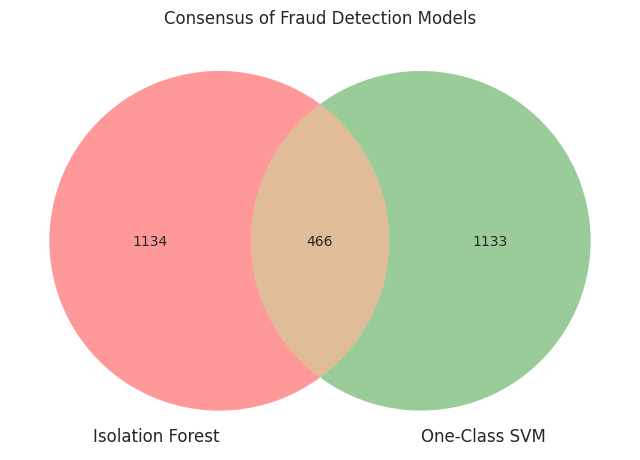

In [331]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Create a Venn Diagram of the Flags
plt.figure(figsize=(8, 8))
venn = venn2(subsets = (
    len(df_ml[df_ml['anomaly_flag'] == -1]), # Isolation Forest only
    len(df_ml[df_ml['svm_flag'] == -1]),     # SVM only
    len(df_ml[df_ml['high_confidence_fraud'] == True]) # Both
), set_labels = ('Isolation Forest', 'One-Class SVM'))

plt.title("Consensus of Fraud Detection Models")
plt.show()

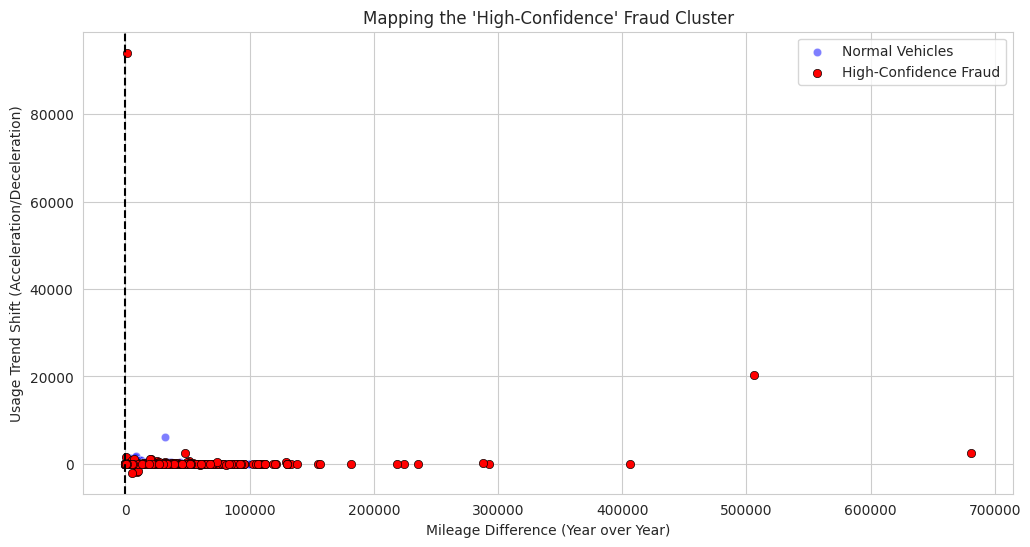

In [332]:
import seaborn as sns

plt.figure(figsize=(12, 6))

# Plot normal cars in grey
sns.scatterplot(data=df_ml[df_ml['high_confidence_fraud'] == False],
                x='mileage_diff', y='usage_trend_shift',
                color='blue', alpha=0.5, label='Normal Vehicles')

# Plot the 500 High-Confidence cars in Red
sns.scatterplot(data=df_ml[df_ml['high_confidence_fraud'] == True],
                x='mileage_diff', y='usage_trend_shift',
                color='red', edgecolor='black',  label='High-Confidence Fraud')

plt.axvline(0, color='black', linestyle='--') # Mark the 'Impossible' 0 line
plt.title("Mapping the 'High-Confidence' Fraud Cluster")
plt.xlabel("Mileage Difference (Year over Year)")
plt.ylabel("Usage Trend Shift (Acceleration/Deceleration)")
plt.legend()
plt.show()

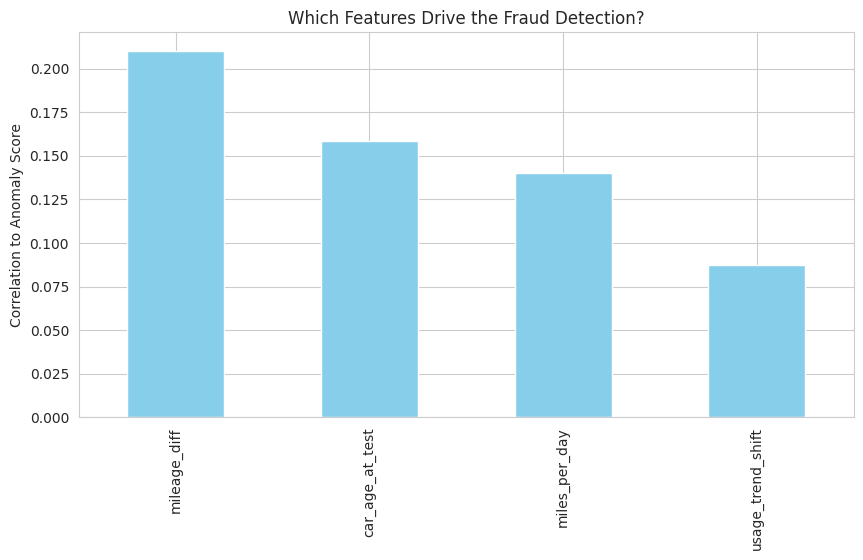

In [333]:
import pandas as pd
import matplotlib.pyplot as plt
df_ml['svm_score'] = svm_model.decision_function(scaled_svm_data)
# Isolation Forest doesn't have a direct 'feature_importances_'
# but we can check the correlation of features to the anomaly score
correlations = df_ml[features_svm].corrwith(df_ml['svm_score']).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
correlations.plot(kind='bar', color='skyblue')
plt.title("Which Features Drive the Fraud Detection?")
plt.ylabel("Correlation to Anomaly Score")
plt.show()

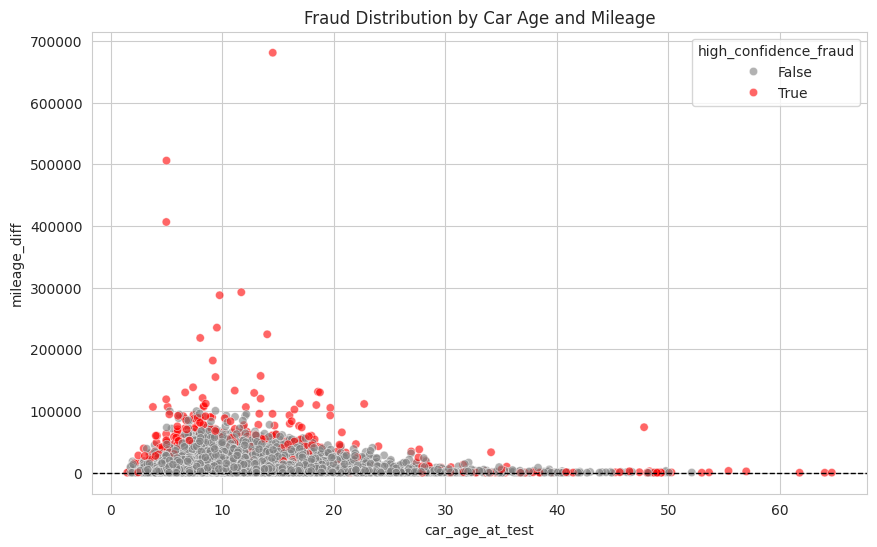

In [334]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Compare Age vs Mileage Diff for Fraud vs Normal
sns.scatterplot(data=df_ml, x='car_age_at_test', y='mileage_diff',
                hue='high_confidence_fraud', palette={True: 'red', False: 'grey'},
                alpha=0.6)

plt.title("Fraud Distribution by Car Age and Mileage")
plt.axhline(0, color='black', lw=1, ls='--')
plt.show()

In [335]:
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Standard Scaler
# This uses Mean and Standard Deviation: (x - mean) / std
std_scaler = StandardScaler()

# 2. Fit and Transform the ML features
# Make sure df_ml is cleaned of Infinities first!
df_ml[features_svm] = df_ml[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)
scaled_std_data = std_scaler.fit_transform(df_ml[features_ml])

# 3. Initialize the Elliptic Envelope
# We keep contamination at 0.03 for a fair comparison
ee_std_model = EllipticEnvelope(contamination=0.03, random_state=42)

# 4. Fit the model to the Standard-Scaled data
df_ml['ee_std_flag'] = ee_std_model.fit_predict(scaled_std_data)

# 5. Get the Decision Score (Statistical Distance)
df_ml['ee_std_score'] = ee_std_model.decision_function(scaled_std_data)

print(f"Standard-Scaled EE flagged: {len(df_ml[df_ml['ee_std_flag'] == -1])} vehicles")

NameError: name 'features_ml' is not defined

In [ ]:
from matplotlib_venn import venn3

plt.figure(figsize=(10, 10))
venn3(subsets = (
    set(df_ml[df_ml['anomaly_flag'] == -1].index),
    set(df_ml[df_ml['svm_flag'] == -1].index),
    set(df_ml[df_ml['ee_flag'] == -1].index)
), set_labels = ('Isolation Forest', 'One-Class SVM', 'Elliptic Envelope'))

plt.title("Triple-Model Consensus: The Core Fraud Group")
plt.show()